# Dataset Preprocessing

This notebook prepares the cleaned dataset for model training using the preprocessing pipeline implemented in `src/preprocessing.py`.

Pipeline:

1. Load cleaned dataset
2. Build dataset dataframe
3. Perform stratified train/validation/test split
4. Create TensorFlow datasets
5. Resize images
6. Apply EfficientNetV2 preprocessing
7. Batch, cache, and prefetch datasets

In [1]:
from pathlib import Path
import sys
import shutil

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import DatasetPreprocessor

In [2]:
preprocessor = DatasetPreprocessor()

2026-07-07 23:35:08 | INFO     | ======================================================================
2026-07-07 23:35:08 | INFO     | Dataset Preprocessing Initialized
2026-07-07 23:35:08 | INFO     | Dataset : C:\Users\HELGA\Documents\AI_Human_Detection\dataset_clean
2026-07-07 23:35:08 | INFO     | ======================================================================


In [3]:
bundle = preprocessor.run()

2026-07-07 23:35:08 | INFO     | ======================================================================
2026-07-07 23:35:08 | INFO     | START PREPROCESSING
2026-07-07 23:35:08 | INFO     | ======================================================================
2026-07-07 23:35:08 | INFO     | Dataset loaded : 1051 images
2026-07-07 23:35:08 | INFO     | Train      : 735
2026-07-07 23:35:08 | INFO     | Validation : 158
2026-07-07 23:35:08 | INFO     | Test       : 158
2026-07-07 23:35:08 | INFO     | ======================================================================
2026-07-07 23:35:08 | INFO     | DATASET STATISTICS
2026-07-07 23:35:08 | INFO     | ======================================================================
2026-07-07 23:35:08 | INFO     | Total Images : 1051
2026-07-07 23:35:08 | INFO     | Train Images : 735
2026-07-07 23:35:08 | INFO     | Validation Images : 158
2026-07-07 23:35:08 | INFO     | Test Images : 158
2026-07-07 23:35:08 | INFO     | =====================

In [4]:
preprocessor.summary_statistics()

DatasetStatistics(total_images=1051, train_images=735, validation_images=158, test_images=158)

In [5]:
bundle.train_summary

,class_name,images
0,AI,376
1,Authentic,359


In [6]:
bundle.validation_summary

,class_name,images
0,AI,81
1,Authentic,77


In [7]:
bundle.test_summary

,class_name,images
0,AI,80
1,Authentic,78


In [8]:
distribution = preprocessor.class_distribution()

distribution

,class_name,images
0,AI,537
1,Authentic,514


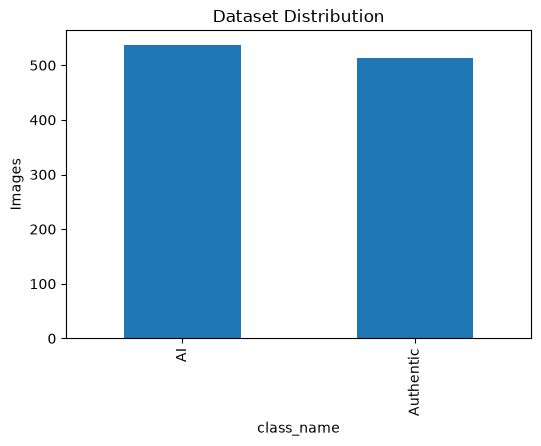

In [9]:
ax = distribution.plot.bar(
    x="class_name",
    y="images",
    legend=False,
    figsize=(6,4),
)

ax.set_ylabel("Images")
ax.set_title("Dataset Distribution")

plt.show()

In [10]:
bundle.train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [11]:
bundle.validation_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [12]:
bundle.test_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [13]:
images, labels = next(iter(bundle.train_dataset))

images.shape, labels.shape

(TensorShape([32, 224, 224, 3]), TensorShape([32]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..120.89136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.3570557..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5816473..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for ims

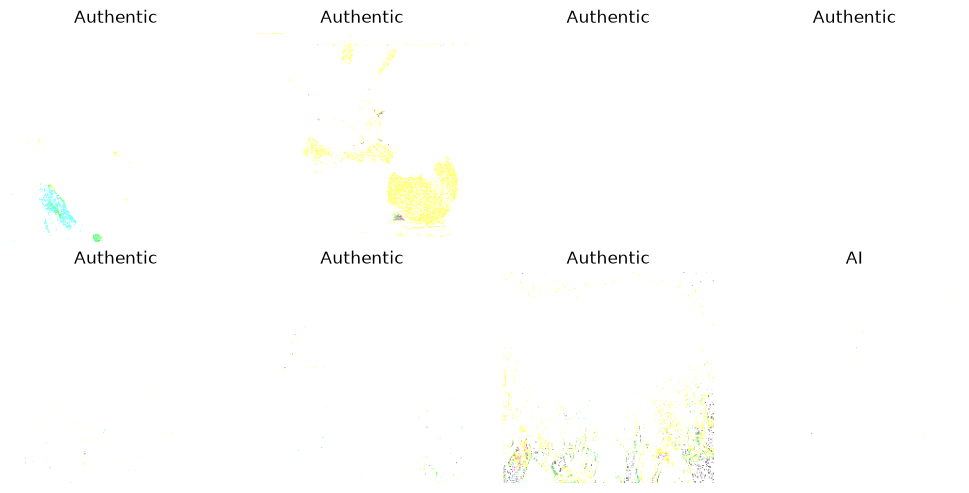

In [14]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(10,5),
)

for image, label, axis in zip(
    images[:8],
    labels[:8],
    axes.ravel(),
):
    axis.imshow((image + 1) / 2)
    axis.set_title(bundle.class_names[int(label)])
    axis.axis("off")

plt.tight_layout()

In [15]:
print("Total      :", preprocessor.dataset_size())
print("Classes    :", preprocessor.number_of_classes())
print("Train      :", len(bundle.train_dataframe))
print("Validation :", len(bundle.validation_dataframe))
print("Test       :", len(bundle.test_dataframe))

Total      : 1051
Classes    : 2
Train      : 735
Validation : 158
Test       : 158


## Conclusion

The preprocessing pipeline completed successfully.

- Dataset loaded successfully.
- Stratified train/validation/test split completed.
- TensorFlow datasets created.
- Images resized to 224×224.
- EfficientNetV2 preprocessing applied.
- Datasets cached and prefetched for efficient training.